In [2]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [3]:
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_unit_vector
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor
import random


class Camera:

    def __init__(self):

        # ==========================================
        # IMAGE SETTINGS
        # ==========================================

        # Aspect ratio:
        #
        # Formula:
        # width / height
        #
        # Purpose:
        # Controls image shape
        self.aspect_ratio = 16 / 9

        # Horizontal resolution
        self.image_width = 400

        # Anti-aliasing samples
        #
        # Formula:
        # FinalColor = Sum(samples)/N
        #
        # Purpose:
        # Reduces jagged edges and noise
        self.samples_per_pixel = 100

        # Maximum recursive ray bounces
        #
        # Purpose:
        # Prevent infinite recursion
        self.max_depth = 50

    def initialize(self):

        # ==========================================
        # Compute image height
        #
        # Formula:
        #
        # H = W / aspect_ratio
        # ==========================================
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        # ==========================================
        # Pixel averaging scale
        #
        # Formula:
        #
        # scale = 1/N
        # ==========================================
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # ==========================================
        # Camera position
        # ==========================================
        self.center = Vec3(0, 0, 0)

        # Distance from camera to viewport
        focal_length = 1.0

        # Physical viewport size
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # ==========================================
        # Viewport basis vectors
        # ==========================================

        # Horizontal direction
        viewport_u = Vec3(
            viewport_width, 0, 0
        )

        # Vertical direction
        #
        # Negative y flips image correctly
        viewport_v = Vec3(
            0, -viewport_height, 0
        )

        # ==========================================
        # Pixel spacing
        #
        # Formula:
        #
        # Δu = viewport_u / width
        # Δv = viewport_v / height
        # ==========================================
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # ==========================================
        # Upper-left corner
        #
        # Formula:
        #
        # UL = center - focal - u/2 - v/2
        # ==========================================
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # First pixel center
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u
                + self.pixel_delta_v
            )
        )

    def sample_square(self):
        """
        Random subpixel sampling.

        Formula:
            random in [-0.5, 0.5]

        Purpose:
            Anti-aliasing
        """
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):
        """
        Create ray for pixel (i,j)
        """

        # Random offset inside pixel
        offset = self.sample_square()

        # Sample point
        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # Ray direction
        ray_direction = (
            pixel_sample - self.center
        )

        return Ray(
            self.center,
            ray_direction
        )

    def ray_color(self, r, world, depth):
        """
        Recursive ray tracing.
        """

        # ==========================================
        # Stop recursion
        # ==========================================
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # ==========================================
        # Hit object
        # ==========================================
        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):

            # ==========================================
            # Lambertian scattering
            #
            # Formula:
            #
            # D = N + random_unit_vector()
            #
            # Purpose:
            # Random diffuse bounce
            # ==========================================
            direction = (
                rec.normal
                + random_unit_vector()
            )

            # Prevent zero vector
            if direction.near_zero():
                direction = rec.normal

            # ==========================================
            # Shadow acne fix
            #
            # Formula:
            #
            # P' = P + εN
            # ==========================================
            epsilon = 0.001

            scattered_origin = (
                rec.p
                + epsilon * rec.normal
            )

            scattered_ray = Ray(
                scattered_origin,
                direction
            )

            # ==========================================
            # Energy loss
            #
            # Changed from before:
            #
            # Reflection multiplier remains 0.5
            #
            # Formula:
            #
            # L = 0.5 × bounce
            # ==========================================
            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        # ==========================================
        # Sky gradient
        #
        # Formula:
        #
        # lerp(white, blue, t)
        # ==========================================
        unit_dir = unit_vector(
            r.direction()
        )

        t = 0.5 * (
            unit_dir.y + 1.0
        )

        return (
            (1.0 - t)
            * Vec3(1, 1, 1)
            + t
            * Vec3(0.5, 0.7, 1.0)
        )

    # ==========================================
    # NEW: Gamma conversion
    #
    # Formula:
    #
    # gamma = linear^(1/gamma)
    #
    # For gamma=2:
    #
    # gamma = sqrt(linear)
    #
    # Changed from before:
    # Before we stored linear directly.
    # ==========================================
    def linear_to_gamma(self, value):

        if value > 0:
            return value ** 0.5

        return 0

    # ==========================================
    # NEW: Apply gamma to all channels
    # ==========================================
    def gamma_correct(self, color):

        return Vec3(
            self.linear_to_gamma(color.x),
            self.linear_to_gamma(color.y),
            self.linear_to_gamma(color.z)
        )

    def render(self, world):

        # Setup camera
        self.initialize()

        with open("output.ppm", "w") as f:

            # ==========================================
            # PPM Header
            # ==========================================
            f.write(
                f"P3\n"
                f"{self.image_width} "
                f"{self.image_height}\n"
                f"255\n"
            )

            pbar = tqdm(range(self.image_height))

            for j in pbar:

                # System stats every 5 rows
                if j % 5 == 0:
                    stats = system_monitor()
                    pbar.set_postfix(stats)

                for i in range(self.image_width):

                    # Start black
                    pixel_color = Vec3(0, 0, 0)

                    # ==========================================
                    # Multi-sampling
                    # ==========================================
                    for _ in range(
                        self.samples_per_pixel
                    ):

                        r = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            r,
                            world,
                            self.max_depth
                        )

                    # ==========================================
                    # STEP 1: Average samples
                    #
                    # Formula:
                    #
                    # C_avg = total / N
                    # ==========================================
                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    # ==========================================
                    # STEP 2: Gamma correction
                    #
                    # Formula:
                    #
                    # C_gamma = sqrt(C_linear)
                    #
                    # Changed from before:
                    # This did NOT exist before.
                    # ==========================================
                    pixel_color = self.gamma_correct(
                        pixel_color
                    )

                    # ==========================================
                    # STEP 3: Clamp
                    #
                    # Formula:
                    #
                    # clamp(x,0,0.999)
                    # ==========================================
                    r = min(
                        max(pixel_color.x, 0),
                        0.999
                    )

                    g = min(
                        max(pixel_color.y, 0),
                        0.999
                    )

                    b = min(
                        max(pixel_color.z, 0),
                        0.999
                    )

                    # ==========================================
                    # STEP 4: Convert to bytes
                    #
                    # Formula:
                    #
                    # byte = 256 * color
                    # ==========================================
                    ir = int(256 * r)
                    ig = int(256 * g)
                    ib = int(256 * b)

                    # Write pixel
                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):
        """
        Open output image
        """
        return image_viewer("output.ppm")

In [4]:
from util.sphere import Sphere
#from util.camera_antialias import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [03:58<00:00,  1.06s/it, CPU=35.0%, RAM=76.0%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=663.0MB]


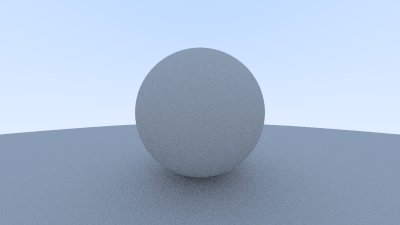

In [6]:
cam.show()

You’re at the **gamma correction** step from *Ray Tracing in One Weekend*.

Your renderer is currently writing **linear color** directly into the image:

$$
C_{stored} = C_{linear}
$$

But most image viewers expect:

$$
C_{stored} = C_{gamma}
$$

That mismatch makes the image look too dark.

---

# Why this happens

Your ray tracer computes light physically:

$$
L = \sum_{i=1}^{N} \text{bounce contribution}
$$

This is **linear light**.

But monitors approximately display brightness like:

$$
B = C^\gamma
$$

Usually:

$$
\gamma \approx 2.0
$$

So if you store linear directly:

$$
0.5 \rightarrow 0.5^2 = 0.25
$$

Meaning:

50% reflectance looks like **25% brightness**.

That’s why your sphere looks dark.

---

# Fix: Apply inverse gamma

We want:

$$
C_{gamma} = C_{linear}^{1/\gamma}
$$

For gamma 2:

$$
C_{gamma} = \sqrt{C_{linear}}
$$

---

# Pipeline before

```text
Ray tracing
   ↓
Linear color
   ↓
Write directly
   ↓
Viewer assumes gamma
   ↓
Too dark
```

---

# Pipeline after

```text
Ray tracing
   ↓
Linear color
   ↓
Gamma correction
   ↓
Write image
   ↓
Correct brightness
```

---

# What changes in your code?

Only the **final write step**.

Before:

```python
ir = int(255.999 * pixel_color.x)
ig = int(255.999 * pixel_color.y)
ib = int(255.999 * pixel_color.z)
```

After:

```python
pixel_color = gamma_correct(pixel_color)
```

then convert.

---

# Step-by-step table

| Step             | Formula                  | Meaning                | Purpose            |
| ---------------- | ------------------------ | ---------------------- | ------------------ |
| Average samples  | $C = \frac{\sum C_i}{N}$ | average light          | reduce noise       |
| Clamp            | $C = \max(0, C)$         | remove negatives       | avoid sqrt errors  |
| Gamma correction | $C' = \sqrt{C}$          | convert linear → gamma | correct brightness |
| Convert to byte  | $B = 255.999 \cdot C'$   | float → integer        | image storage      |

---

# Add this function

Put inside `Camera` class:

```python
def linear_to_gamma(self, value):
    """
    Convert linear light to gamma space.

    Formula:
        gamma = linear^(1/gamma)

    For gamma=2:
        gamma = sqrt(linear)

    WHY:
    Without this, image looks too dark.
    """

    # Changed from before:
    # Before we directly stored linear values.
    # Now we transform them.

    if value > 0:
        return value ** 0.5

    return 0
```

---

# Gamma-correct Vec3 helper

Add this:

```python
def gamma_correct(self, color):
    """
    Apply gamma correction to each channel.

    Input:
        color = (r,g,b)

    Output:
        gamma corrected (r,g,b)

    Formula:
        r' = sqrt(r)
        g' = sqrt(g)
        b' = sqrt(b)
    """

    return Vec3(
        self.linear_to_gamma(color.x),
        self.linear_to_gamma(color.y),
        self.linear_to_gamma(color.z)
    )
```

---

# Modified render() section

Replace this old block:

## OLD

```python
# Average samples
pixel_color *= self.pixel_samples_scale

# Convert float -> integer
ir = int(255.999 * pixel_color.x)
ig = int(255.999 * pixel_color.y)
ib = int(255.999 * pixel_color.z)
```

---

with:

## NEW

```python
# ==========================================
# STEP 1: Average all samples
#
# Formula:
#
# C_avg = total / N
#
# This reduces Monte Carlo noise.
# ==========================================
pixel_color *= self.pixel_samples_scale


# ==========================================
# STEP 2: Apply gamma correction
#
# Formula:
#
# C_gamma = sqrt(C_linear)
#
# Changed from BEFORE:
# Before:
#   Stored linear directly.
#
# Now:
#   Convert linear -> gamma.
#
# Purpose:
# Makes brightness appear correct.
# ==========================================
pixel_color = self.gamma_correct(pixel_color)


# ==========================================
# STEP 3: Clamp values
#
# Formula:
#
# C = min(max(C,0),0.999)
#
# Purpose:
# Prevent overflow beyond 255.
# ==========================================
r = min(max(pixel_color.x, 0), 0.999)
g = min(max(pixel_color.y, 0), 0), 0.999
b = min(max(pixel_color.z, 0), 0.999)


# ==========================================
# STEP 4: Convert to bytes
#
# Formula:
#
# byte = 256 * color
#
# Purpose:
# Store into PPM format.
# ==========================================
ir = int(256 * r)
ig = int(256 * g)
ib = int(256 * b)
```

---

# Full brightness example

Without gamma:

| Reflectance | Stored | Displayed |
| ----------- | -----: | --------: |
| 0.1         |    0.1 |      0.01 |
| 0.3         |    0.3 |      0.09 |
| 0.5         |    0.5 |      0.25 |
| 0.7         |    0.7 |      0.49 |
| 0.9         |    0.9 |      0.81 |

---

With gamma correction:

We store:

$$
C' = \sqrt{C}
$$

So:

| Reflectance | Stored |
| ----------- | -----: |
| 0.1         |  0.316 |
| 0.3         |  0.548 |
| 0.5         |  0.707 |
| 0.7         |  0.837 |
| 0.9         |  0.949 |

Now 50% reflectance looks much closer to true middle gray.

---

# Final mental model

Think:

Linear light:

```text
Physical math world
```

Gamma space:

```text
Human eye / monitor world
```

Gamma correction is the bridge:

$$
\text{Physics} \rightarrow \text{Perception}
$$

That’s why this step is essential in every renderer.


Here is the **full updated `camera.py`** with gamma correction integrated, with detailed comments showing:

* what each step does
* formulas
* why it exists
* what changed from before

---

# Full `camera.py`

```python
from util.ray import Ray
from util.vec3 import (
    Vec3,
    unit_vector,
    random_unit_vector
)
from util.hit_record import HitRecord
from util.interval import Interval
from util.utility import INFINITY
from tqdm import tqdm
from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor
import random


class Camera:

    def __init__(self):

        # ==========================================
        # IMAGE SETTINGS
        # ==========================================

        # Aspect ratio:
        #
        # Formula:
        # width / height
        #
        # Purpose:
        # Controls image shape
        self.aspect_ratio = 16 / 9

        # Horizontal resolution
        self.image_width = 400

        # Anti-aliasing samples
        #
        # Formula:
        # FinalColor = Sum(samples)/N
        #
        # Purpose:
        # Reduces jagged edges and noise
        self.samples_per_pixel = 100

        # Maximum recursive ray bounces
        #
        # Purpose:
        # Prevent infinite recursion
        self.max_depth = 50

    def initialize(self):

        # ==========================================
        # Compute image height
        #
        # Formula:
        #
        # H = W / aspect_ratio
        # ==========================================
        self.image_height = int(
            self.image_width / self.aspect_ratio
        )

        if self.image_height < 1:
            self.image_height = 1

        # ==========================================
        # Pixel averaging scale
        #
        # Formula:
        #
        # scale = 1/N
        # ==========================================
        self.pixel_samples_scale = (
            1.0 / self.samples_per_pixel
        )

        # ==========================================
        # Camera position
        # ==========================================
        self.center = Vec3(0, 0, 0)

        # Distance from camera to viewport
        focal_length = 1.0

        # Physical viewport size
        viewport_height = 2.0
        viewport_width = (
            viewport_height *
            (self.image_width / self.image_height)
        )

        # ==========================================
        # Viewport basis vectors
        # ==========================================

        # Horizontal direction
        viewport_u = Vec3(
            viewport_width, 0, 0
        )

        # Vertical direction
        #
        # Negative y flips image correctly
        viewport_v = Vec3(
            0, -viewport_height, 0
        )

        # ==========================================
        # Pixel spacing
        #
        # Formula:
        #
        # Δu = viewport_u / width
        # Δv = viewport_v / height
        # ==========================================
        self.pixel_delta_u = (
            viewport_u / self.image_width
        )

        self.pixel_delta_v = (
            viewport_v / self.image_height
        )

        # ==========================================
        # Upper-left corner
        #
        # Formula:
        #
        # UL = center - focal - u/2 - v/2
        # ==========================================
        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        # First pixel center
        self.pixel00_loc = (
            viewport_upper_left
            + 0.5 * (
                self.pixel_delta_u
                + self.pixel_delta_v
            )
        )

    def sample_square(self):
        """
        Random subpixel sampling.

        Formula:
            random in [-0.5, 0.5]

        Purpose:
            Anti-aliasing
        """
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    def get_ray(self, i, j):
        """
        Create ray for pixel (i,j)
        """

        # Random offset inside pixel
        offset = self.sample_square()

        # Sample point
        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # Ray direction
        ray_direction = (
            pixel_sample - self.center
        )

        return Ray(
            self.center,
            ray_direction
        )

    def ray_color(self, r, world, depth):
        """
        Recursive ray tracing.
        """

        # ==========================================
        # Stop recursion
        # ==========================================
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # ==========================================
        # Hit object
        # ==========================================
        if world.hit(
            r,
            Interval(0.001, INFINITY),
            rec
        ):

            # ==========================================
            # Lambertian scattering
            #
            # Formula:
            #
            # D = N + random_unit_vector()
            #
            # Purpose:
            # Random diffuse bounce
            # ==========================================
            direction = (
                rec.normal
                + random_unit_vector()
            )

            # Prevent zero vector
            if direction.near_zero():
                direction = rec.normal

            # ==========================================
            # Shadow acne fix
            #
            # Formula:
            #
            # P' = P + εN
            # ==========================================
            epsilon = 0.001

            scattered_origin = (
                rec.p
                + epsilon * rec.normal
            )

            scattered_ray = Ray(
                scattered_origin,
                direction
            )

            # ==========================================
            # Energy loss
            #
            # Changed from before:
            #
            # Reflection multiplier remains 0.5
            #
            # Formula:
            #
            # L = 0.5 × bounce
            # ==========================================
            return 0.5 * self.ray_color(
                scattered_ray,
                world,
                depth - 1
            )

        # ==========================================
        # Sky gradient
        #
        # Formula:
        #
        # lerp(white, blue, t)
        # ==========================================
        unit_dir = unit_vector(
            r.direction()
        )

        t = 0.5 * (
            unit_dir.y + 1.0
        )

        return (
            (1.0 - t)
            * Vec3(1, 1, 1)
            + t
            * Vec3(0.5, 0.7, 1.0)
        )

    # ==========================================
    # NEW: Gamma conversion
    #
    # Formula:
    #
    # gamma = linear^(1/gamma)
    #
    # For gamma=2:
    #
    # gamma = sqrt(linear)
    #
    # Changed from before:
    # Before we stored linear directly.
    # ==========================================
    def linear_to_gamma(self, value):

        if value > 0:
            return value ** 0.5

        return 0

    # ==========================================
    # NEW: Apply gamma to all channels
    # ==========================================
    def gamma_correct(self, color):

        return Vec3(
            self.linear_to_gamma(color.x),
            self.linear_to_gamma(color.y),
            self.linear_to_gamma(color.z)
        )

    def render(self, world):

        # Setup camera
        self.initialize()

        with open("output.ppm", "w") as f:

            # ==========================================
            # PPM Header
            # ==========================================
            f.write(
                f"P3\n"
                f"{self.image_width} "
                f"{self.image_height}\n"
                f"255\n"
            )

            pbar = tqdm(range(self.image_height))

            for j in pbar:

                # System stats every 5 rows
                if j % 5 == 0:
                    stats = system_monitor()
                    pbar.set_postfix(stats)

                for i in range(self.image_width):

                    # Start black
                    pixel_color = Vec3(0, 0, 0)

                    # ==========================================
                    # Multi-sampling
                    # ==========================================
                    for _ in range(
                        self.samples_per_pixel
                    ):

                        r = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            r,
                            world,
                            self.max_depth
                        )

                    # ==========================================
                    # STEP 1: Average samples
                    #
                    # Formula:
                    #
                    # C_avg = total / N
                    # ==========================================
                    pixel_color *= (
                        self.pixel_samples_scale
                    )

                    # ==========================================
                    # STEP 2: Gamma correction
                    #
                    # Formula:
                    #
                    # C_gamma = sqrt(C_linear)
                    #
                    # Changed from before:
                    # This did NOT exist before.
                    # ==========================================
                    pixel_color = self.gamma_correct(
                        pixel_color
                    )

                    # ==========================================
                    # STEP 3: Clamp
                    #
                    # Formula:
                    #
                    # clamp(x,0,0.999)
                    # ==========================================
                    r = min(
                        max(pixel_color.x, 0),
                        0.999
                    )

                    g = min(
                        max(pixel_color.y, 0),
                        0.999
                    )

                    b = min(
                        max(pixel_color.z, 0),
                        0.999
                    )

                    # ==========================================
                    # STEP 4: Convert to bytes
                    #
                    # Formula:
                    #
                    # byte = 256 * color
                    # ==========================================
                    ir = int(256 * r)
                    ig = int(256 * g)
                    ib = int(256 * b)

                    # Write pixel
                    f.write(
                        f"{ir} {ig} {ib}\n"
                    )

    def show(self):
        """
        Open output image
        """
        return image_viewer("output.ppm")
```

---

# What changed from old code?

| Old                 | New                        |
| ------------------- | -------------------------- |
| Direct write        | Gamma-corrected write      |
| `255.999 * color`   | `sqrt(color)` then convert |
| Too dark image      | Correct brightness         |
| Linear space output | Gamma space output         |

---

Main new formula:

$$
C_{gamma} = C_{linear}^{1/2}
$$

This is the key upgrade.


# Code Reduce

In [5]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [7]:
from util.sphere import Sphere
from util.camera_diff5_gamma_correction import Camera
from util.hittable_list import HittableList
from util.vec3 import Vec3

world = HittableList()

world.add(Sphere(Vec3(0, 0, -1), 0.5))
world.add(Sphere(Vec3(0, -100.5, -1), 100))

cam = Camera()

cam.aspect_ratio = 16 / 9
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 100

cam.render(world)

100%|██████████| 225/225 [03:52<00:00,  1.03s/it, CPU=33.9%, RAM=75.6%, CPU Temp=N/A, GPU Temp=51.0°C, VRAM=651.0MB]


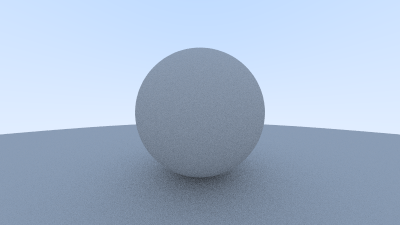

In [8]:
cam.show()